<a href="https://www.kaggle.com/code/lalit7881/global-healthcare-pharma-2010-26-eda-88?scriptVersionId=331202104" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
from pathlib import Path
from datetime import datetime

# Suppress warnings
warnings.filterwarnings('ignore')

# Matplotlib configuration
plt.switch_backend('Agg')
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Set seaborn style
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/clinical_trials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/biotech_funding.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/pharma_companies_financials.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/drug_approvals.csv
/kaggle/input/datasets/sergionefedov/global-healthcare-and-pharma-2010-2026/disease_burden.csv


## Loading dataset

In [2]:
# Helper function to resolve data file paths
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets')
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')


In [3]:
drug_file = resolve_data_file(file_name='drug_approvals.csv')
drug_df = pd.read_csv(drug_file, encoding='utf-8')

# Convert approval_date to datetime (inferring date type)
drug_df['approval_date'] = pd.to_datetime(drug_df['approval_date'], errors='coerce')

print('Drug Approvals Data Loaded. Number of records:', drug_df.shape[0])

Drug Approvals Data Loaded. Number of records: 722


In [4]:
disease_file = resolve_data_file(file_name='disease_burden.csv')
disease_df = pd.read_csv(disease_file, encoding='ascii')

print('Disease Burden Data Loaded. Number of records:', disease_df.shape[0])

Disease Burden Data Loaded. Number of records: 3310


In [5]:
financials_file = resolve_data_file(file_name='pharma_companies_financials.csv')
financials_df = pd.read_csv(financials_file, encoding='ascii')

print('Pharma Companies Financials Data Loaded. Number of records:', financials_df.shape[0])

Pharma Companies Financials Data Loaded. Number of records: 489


In [6]:
funding_file = resolve_data_file(file_name='biotech_funding.csv')
funding_df = pd.read_csv(funding_file, encoding='ascii')

# Convert date column to datetime
funding_df['date'] = pd.to_datetime(funding_df['date'], errors='coerce')

print('Biotech Funding Data Loaded. Number of records:', funding_df.shape[0])

Biotech Funding Data Loaded. Number of records: 1208


In [7]:
trials_file = resolve_data_file(file_name='clinical_trials.csv')
trials_df = pd.read_csv(trials_file, encoding='ascii')

# Convert completion_date to datetime
trials_df['completion_date'] = pd.to_datetime(trials_df['completion_date'], errors='coerce')

print('Clinical Trials Data Loaded. Number of records:', trials_df.shape[0])

Clinical Trials Data Loaded. Number of records: 599


## EDA

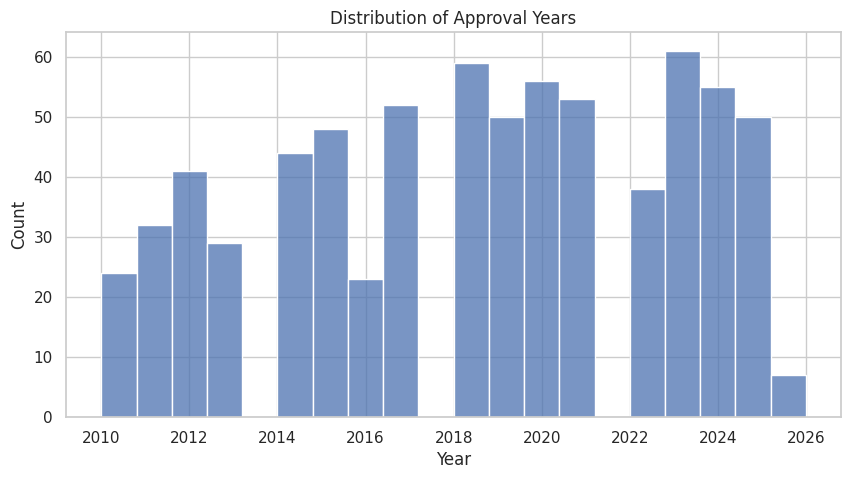

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(drug_df['year'], bins=20, kde=False)
plt.title('Distribution of Approval Years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

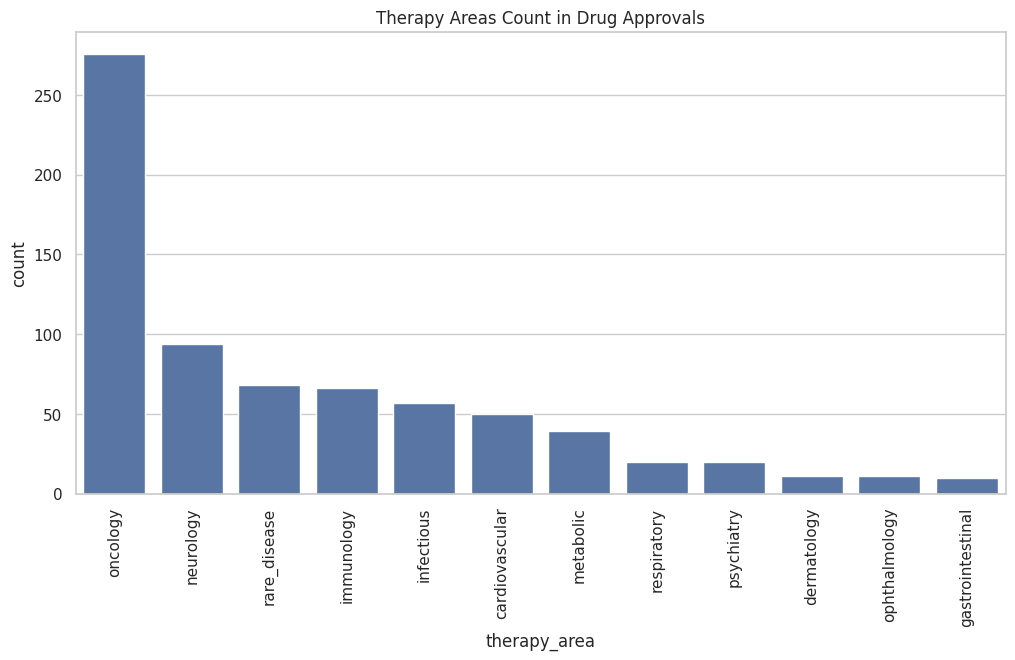

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=drug_df, x='therapy_area', order=drug_df['therapy_area'].value_counts().index)
plt.xticks(rotation=90)
plt.title('Therapy Areas Count in Drug Approvals')
plt.show()

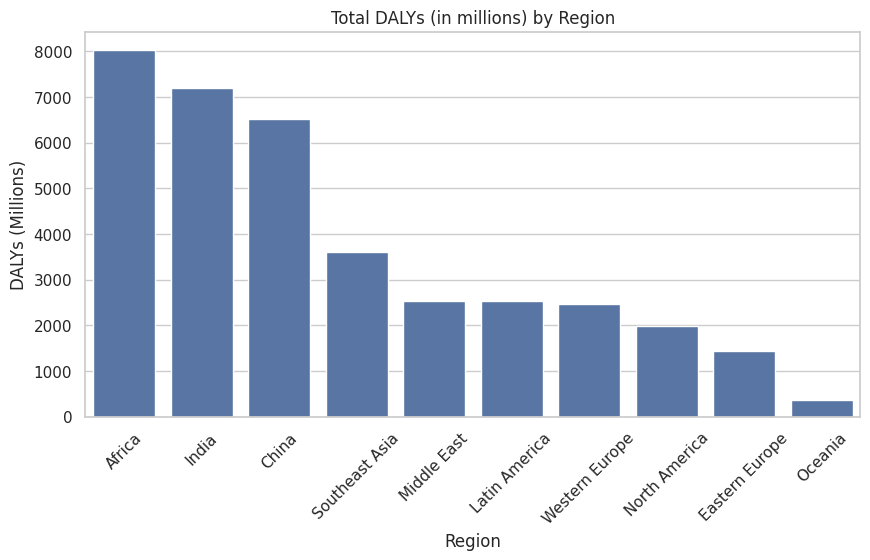

In [10]:
plt.figure(figsize=(10, 5))
sns.barplot(data=disease_df, x='region', y='dalys_millions', ci=None, estimator=sum, order=disease_df.groupby('region')['dalys_millions'].sum().sort_values(ascending=False).index)
plt.title('Total DALYs (in millions) by Region')
plt.xlabel('Region')
plt.ylabel('DALYs (Millions)')
plt.xticks(rotation=45)
plt.show()


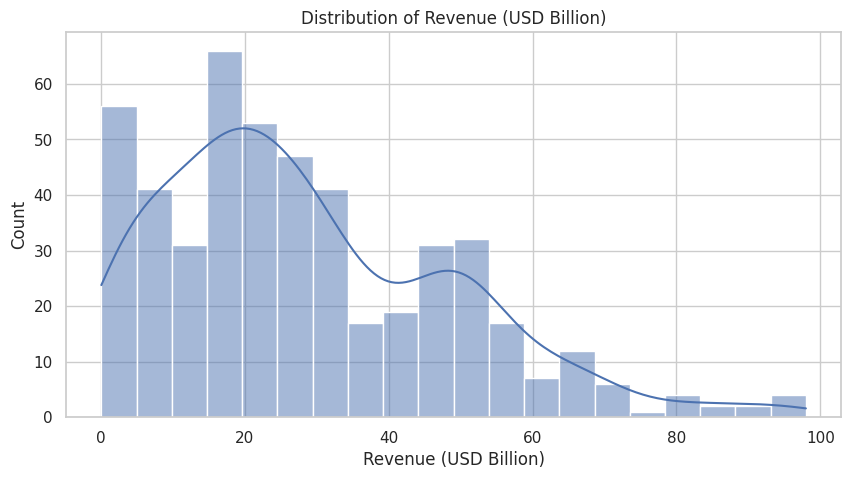

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(financials_df['revenue_usd_bn'], bins=20, kde=True)
plt.title('Distribution of Revenue (USD Billion)')
plt.xlabel('Revenue (USD Billion)')
plt.show()

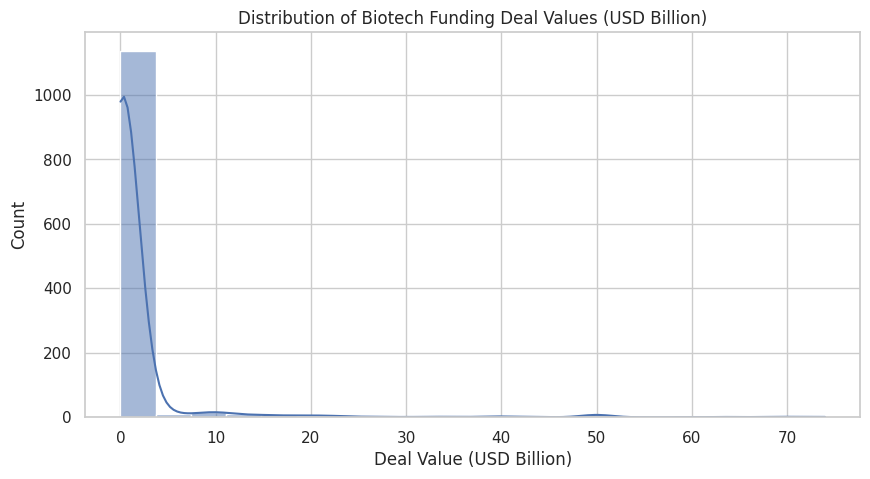

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(funding_df['value_usd_bn'], bins=20, kde=True)
plt.title('Distribution of Biotech Funding Deal Values (USD Billion)')
plt.xlabel('Deal Value (USD Billion)')
plt.show()

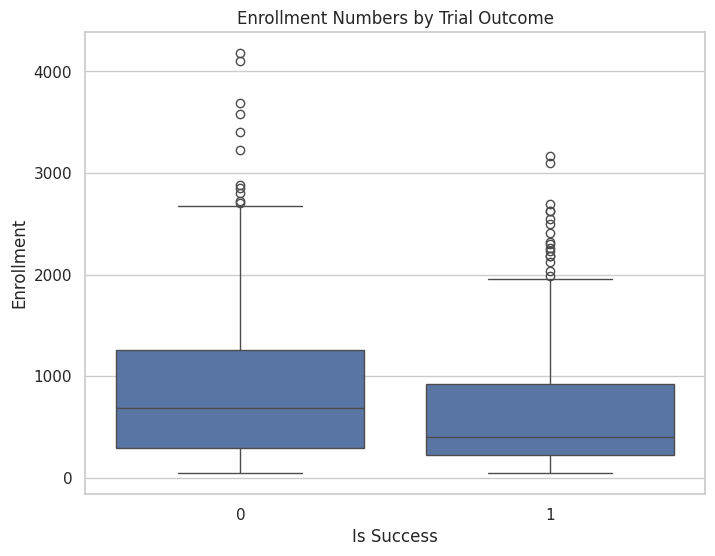

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=trials_df, x='is_success', y='enrollment_n')
plt.title('Enrollment Numbers by Trial Outcome')
plt.xlabel('Is Success')
plt.ylabel('Enrollment')
plt.show()

## Feature engineering

Test Accuracy for Clinical Trials Success Prediction: 0.8833333333333333


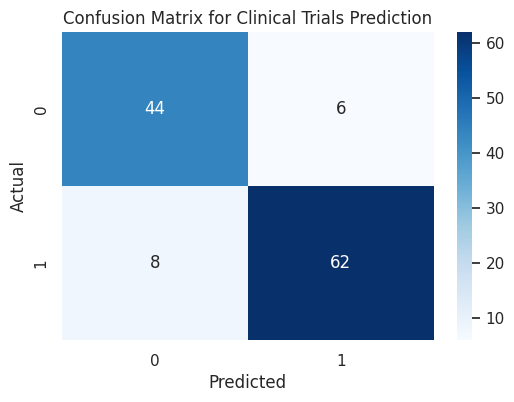

In [14]:
# Prepare the dataset for modeling
model_df = trials_df[['is_success', 'enrollment_n', 'duration_months', 'estimated_stock_impact_pct', 'phase']].copy()

# Drop rows with missing values in our modeling columns
model_df.dropna(inplace=True)

# Define feature matrix X and target vector y
X = model_df.drop('is_success', axis=1)
y = model_df['is_success']

# Let's perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build a preprocessing and modeling pipeline
numeric_features = ['enrollment_n', 'duration_months', 'estimated_stock_impact_pct']
categorical_features = ['phase']

# Preprocessing: One-hot encode the phase column
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Predict on the test set and evaluate accuracy
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Test Accuracy for Clinical Trials Success Prediction:', acc)

# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Clinical Trials Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Thank you...pls upvote!!!!!!!!!